In [1]:
library(pheatmap)
library(RColorBrewer)
library(data.table)
library(dplyr)

setwd("~/HRJ_monocytes/hILCs/COGS_results/cross_trait")

### Get all genes sig in at least one trait.
### Then plot heatmap of the COGS scores across traits, with clustering.
### Make supplementary table as in Javierre, with at least the following tabs:
## 1) Prioritised genes, with a "+" for 0.5 - 0.9 and a "++" for 0.9-1.0 COGS score.
## 2). Raw gene scores.

cd <- fread("../COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/COGS_scores_data.table.txt")
astao <- fread("../COGS_out/ASTAO_Ferreira_30929738/ASTAO_Ferreira_30929738_ILC3_SuSIE/COGS_scores_data.table.txt")
uc <- fread("../COGS_out/UC_DeLange_28067908//UC_DeLange_28067908_ILC3_SuSIE/COGS_scores_data.table.txt")
ibd <- fread("../COGS_out/IBD_DeLange_28067908/IBD_DeLange_28067908_ILC3_SuSIE/COGS_scores_data.table.txt")
cel <- fread("../COGS_out/CEL_Dubois_20190752/CEL_Dubois_20190752_ILC3_SuSIE/COGS_scores_data.table.txt")
psc <- fread("../COGS_out/PSC_Ji_27992413/PSC_Ji_27992413_ILC3_SuSIE/COGS_scores_data.table.txt")

nrow(unique(cd[cogs > 0.5, .(ensg)]))
nrow(unique(astao[cogs > 0.5, .(ensg)]))
nrow(unique(uc[cogs > 0.5, .(ensg)]))
nrow(unique(ibd[cogs > 0.5, .(ensg)]))
nrow(unique(cel[cogs > 0.5, .(ensg)]))
nrow(unique(psc[cogs > 0.5, .(ensg)]))


setnames(cd, "cogs", "CD_ILC3")
setnames(astao, "cogs", "Asthma_ILC3")
setnames(uc, "cogs", "UC_ILC3")
setnames(ibd, "cogs", "IBD_ILC3")
setnames(cel, "cogs", "Celiac_ILC3")
setnames(psc, "cogs", "PSC_ILC3")

cd_astao <- cd[astao, on = "ensg", all = T]
cd_astao_uc <- uc[cd_astao, on = "ensg", all = T]
cd_astao_uc_ibd <- ibd[cd_astao_uc, on  = "ensg", all = T]
cd_astao_uc_ibd_cel <- cel[cd_astao_uc_ibd, on  = "ensg", all = T]
cd_astao_uc_ibd_cel_psc_ILC <- psc[cd_astao_uc_ibd_cel, on  = "ensg", all = T]

sigCogs <- cd_astao_uc_ibd_cel_psc_ILC[IBD_ILC3 > 0.5 | UC_ILC3 > 0.5 | CD_ILC3 > 0.5 | Asthma_ILC3 > 0.5 | Celiac_ILC3 > 0.5 | PSC_ILC3 > 0.5]
sigCogs # 251 genes

### Now add CD4.
cd <- fread("../COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023/COGS_scores_data.table.txt")
astao <- fread("../COGS_out/ASTAO_Ferreira_30929738/ASTAO_Ferreira_30929738_CD4_SuSIE/COGS_scores_data.table.txt")
uc <- fread("../COGS_out/UC_DeLange_28067908//UC_DeLange_28067908_CD4_SuSIE/COGS_scores_data.table.txt")
ibd <- fread("../COGS_out/IBD_DeLange_28067908/IBD_DeLange_28067908_CD4_SuSIE/COGS_scores_data.table.txt")
cel <- fread("../COGS_out/CEL_Dubois_20190752/CEL_Dubois_20190752_CD4_SuSIE/COGS_scores_data.table.txt")
psc <- fread("../COGS_out/PSC_Ji_27992413/PSC_Ji_27992413_CD4_SuSIE/COGS_scores_data.table.txt")

nrow(unique(cd[cogs > 0.5, .(ensg)]))
nrow(unique(astao[cogs > 0.5, .(ensg)]))
nrow(unique(uc[cogs > 0.5, .(ensg)]))
nrow(unique(ibd[cogs > 0.5, .(ensg)]))
nrow(unique(cel[cogs > 0.5, .(ensg)]))
nrow(unique(psc[cogs > 0.5, .(ensg)]))


setnames(cd, "cogs", "CD_CD4")
setnames(astao, "cogs", "Asthma_CD4")
setnames(uc, "cogs", "UC_CD4")
setnames(ibd, "cogs", "IBD_CD4")
setnames(cel, "cogs", "Celiac_CD4")
setnames(psc, "cogs", "PSC_CD4")

cd_astao <- cd[astao, on = "ensg", all = T]
cd_astao_uc <- uc[cd_astao, on = "ensg", all = T]
cd_astao_uc_ibd <- ibd[cd_astao_uc, on  = "ensg", all = T]
cd_astao_uc_ibd_cel <- cel[cd_astao_uc_ibd, on  = "ensg", all = T]
cd_astao_uc_ibd_cel_psc_CD4 <- psc[cd_astao_uc_ibd_cel, on  = "ensg", all = T]

sigCogs <- cd_astao_uc_ibd_cel_psc_CD4[IBD_CD4 > 0.5 | UC_CD4 > 0.5 | CD_CD4 > 0.5 | Asthma_CD4 > 0.5 | Celiac_CD4 > 0.5 | PSC_CD4 > 0.5]
sigCogs # 266 genes

### Both cell types.
both <- cd_astao_uc_ibd_cel_psc_ILC[cd_astao_uc_ibd_cel_psc_CD4, on = "ensg", all = T]

all_sigCOGS <- both[IBD_ILC3 > 0.5 | UC_ILC3 > 0.5 | CD_ILC3 > 0.5 | Asthma_ILC3 > 0.5 | Celiac_ILC3 > 0.5 | PSC_ILC3 > 0.5 | IBD_CD4 > 0.5 | UC_CD4 > 0.5 | CD_CD4 > 0.5 | Asthma_CD4 > 0.5 | Celiac_CD4 > 0.5 | PSC_CD4 > 0.5]
all_sigCOGS
# 332 genes

fwrite_headers(both, file = "./bothCells_cross_trait_allCOGS.txt")


Warning message:
“package ‘pheatmap’ was built under R version 4.1.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] 109

[1] 55

[1] 61

[1] 105

...

[1] 137

[1] 17

[1] 15

ensg,PSC_CD4,Celiac_CD4,IBD_CD4,UC_CD4,CD_CD4,Asthma_CD4
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000166949,0.081717900,3.568565e-03,1.000000e+00,9.998685e-01,1.000000e+00,1.0000000
ENSG00000169189,0.031779055,1.965498e-03,3.719501e-02,3.432812e-02,1.087382e-01,0.9999998
ENSG00000166888,0.009927248,2.505305e-04,1.247468e-02,1.809688e-02,1.901289e-02,0.9999688
ENSG00000197536,0.014129594,3.060243e-02,5.606579e-01,6.815332e-01,3.366388e-01,0.9995591
ENSG00000283782,0.014129594,3.060243e-02,5.606579e-01,6.815332e-01,3.366388e-01,0.9995591
ENSG00000061273,0.113111460,8.873337e-04,4.674540e-01,8.769077e-01,2.479899e-02,0.9960799
ENSG00000155666,0.013472723,1.512810e-03,1.683388e-02,1.519778e-02,3.600536e-02,0.9929429
ENSG00000198821,0.033755113,9.933036e-01,1.300006e-02,1.631808e-02,3.130825e-02,0.9914823
ENSG00000151418,0.077332473,2.248168e-03,7.148429e-01,1.078020e-01,9.987864e-01,0.9858276


ensg,PSC_ILC3,Celiac_ILC3,IBD_ILC3,UC_ILC3,CD_ILC3,Asthma_ILC3,PSC_CD4,Celiac_CD4,IBD_CD4,UC_CD4,CD_CD4,Asthma_CD4
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000166949,0.058178565,2.959723e-03,5.348277e-01,5.328095e-01,0.6836337412,0.7271924,0.081717900,3.568565e-03,1.000000e+00,9.998685e-01,1.000000e+00,1.0000000
ENSG00000169189,0.018707027,8.029313e-04,1.634784e-02,1.795734e-02,0.0440742567,0.8939787,0.031779055,1.965498e-03,3.719501e-02,3.432812e-02,1.087382e-01,0.9999998
ENSG00000166888,0.007156894,2.311371e-04,8.165221e-03,1.244495e-02,0.0149427650,0.9999691,0.009927248,2.505305e-04,1.247468e-02,1.809688e-02,1.901289e-02,0.9999688
ENSG00000197536,0.010439820,2.596828e-02,1.815521e-01,3.636159e-01,0.1095855381,0.9889564,0.014129594,3.060243e-02,5.606579e-01,6.815332e-01,3.366388e-01,0.9995591
ENSG00000283782,0.010973828,3.026497e-02,2.062946e-01,4.196978e-01,0.3130761411,0.9996127,0.014129594,3.060243e-02,5.606579e-01,6.815332e-01,3.366388e-01,0.9995591
ENSG00000061273,0.110883893,8.199771e-04,4.058335e-01,8.441973e-01,0.0210941898,0.9937370,0.113111460,8.873337e-04,4.674540e-01,8.769077e-01,2.479899e-02,0.9960799
ENSG00000155666,0.008239257,8.959236e-04,8.865513e-03,9.500944e-03,0.0131618416,0.7206458,0.013472723,1.512810e-03,1.683388e-02,1.519778e-02,3.600536e-02,0.9929429
ENSG00000198821,0.019377683,6.431615e-01,6.781014e-03,6.245095e-03,0.0282061917,0.7009670,0.033755113,9.933036e-01,1.300006e-02,1.631808e-02,3.130825e-02,0.9914823
ENSG00000151418,0.033241342,1.596628e-03,4.276988e-01,6.224677e-02,0.9976112942,0.1089247,0.077332473,2.248168e-03,7.148429e-01,1.078020e-01,9.987864e-01,0.9858276


png 
  2

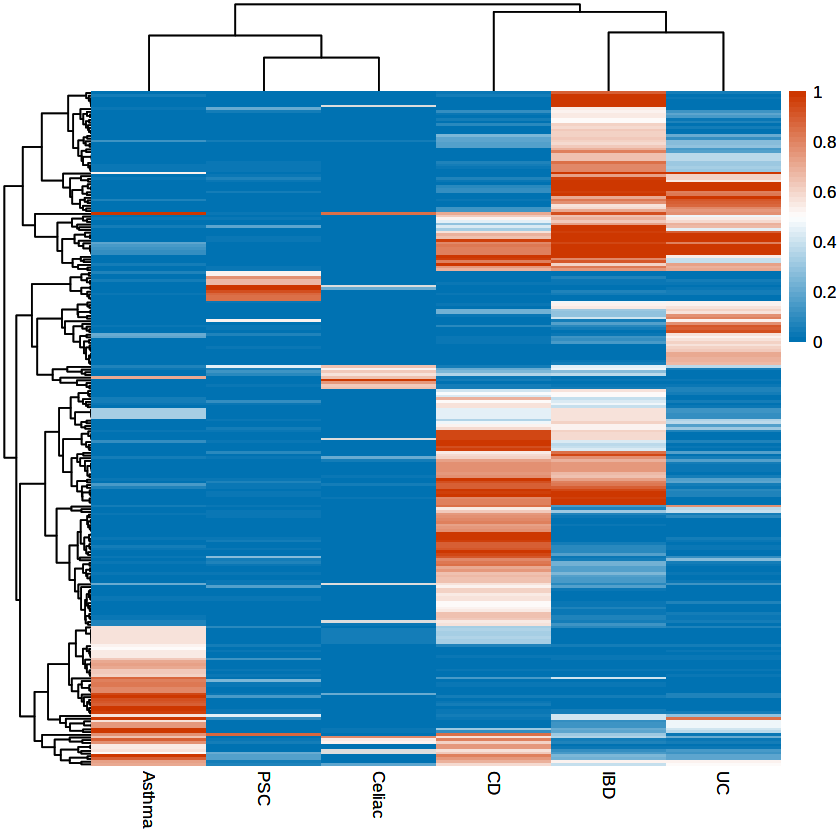

In [2]:
### Make a heatmap.
matrix_prep <- as.data.frame(sigCogs)
rownames(matrix_prep) <- matrix_prep[,1]
mat <- matrix_prep[ -c(1) ]

# make sure center is at zero
paletteLength <- 50
myColor <- colorRampPalette(c("#0072B2", "white", "orangered3"))(paletteLength)
# length(breaks) == length(paletteLength) + 1
# use floor and ceiling to deal with even/odd length pallettelengths
#myBreaks <- c(seq(min(mat, na.rm=T), 0, length.out=ceiling(paletteLength/2) + 1), 
#              seq(max(mat, na.rm=T)/paletteLength, max(mat, na.rm=T), length.out=floor(paletteLength/2)))


p <- pheatmap(mat, cluster_rows = TRUE, cluster_cols = T, color = myColor, show_rownames = F)
p

save_pheatmap_pdf <- function(x, filename, width=6, height=6) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}
save_pheatmap_pdf(p, "./multiCOGSgenes_crossTrait_ILC3_heatmap.pdf")

In [6]:
### Plotting GSEA results and make a supplementary table for GO terms.
setwd("~/HRJ_monocytes/hILCs/COGS_results/cross_trait")
library(data.table)
library(dplyr)
#For the plot:
# y axis is pathways
# x axis is traits
# size of dots is geneRatio
# colour is Padj
# label on the top is total no. of genes analysed for each trait
# Maybe just do this for the most sig enriched pathways
# was done in R (COGs_clusterProfiler_crossTrait.R)
getwd()
list.files()
cd <- fread("./cd_gseGO.txt")
astao <- fread("./astao_gseGO.txt")
uc <- fread("./uc_gseGO.txt")
ibd <- fread("./ibd_gseGO.txt")
cel <- fread("./cel_gseGO.txt")
psc <- fread("./psc_gseGO.txt")

list.files()
# prepare for rbind
cd[, Trait := "CD"]
astao[, Trait := "Asthma"]
uc[, Trait := "UC"]
ibd[, Trait := "IBD"]
cel[, Trait := "Celiac"]
psc[, Trait := "PSC"]

allBound <- rbind(cd[p.adjust < 0.05], astao[p.adjust < 0.05], uc[p.adjust < 0.05], ibd[p.adjust < 0.05], 
                  cel[p.adjust < 0.05], psc[p.adjust < 0.05])
#print(allBound) # 57 pathways

cd_keep <- cd[ID %in% allBound$ID]
astao_keep <- astao[ID %in% allBound$ID]
uc_keep <- uc[ID %in% allBound$ID]
ibd_keep <- ibd[ID %in% allBound$ID]
cel_keep <- cel[ID %in% allBound$ID]
psc_keep <- psc[ID %in% allBound$ID]

allBound2 <- rbind(cd_keep, astao_keep, uc_keep, ibd_keep, 
                  cel_keep, psc_keep)
length(unique(allBound2$ID)) # 23

allBound3 <- as.data.table(allBound2 %>% group_by(ID) %>% mutate(median_p = median(p.adjust)))
setorder(allBound3, -median_p)
setnames(allBound3, "Count", "Gene count")
print(allBound3)


setorder(allBound3, "Trait")
allBound3[, median_p := NULL]

fwrite_headers(allBound3, file= "./GO_allTraits.txt")


### Make plot in next chunk.

[1] "/rds/general/project/lms-spivakov-analysis/live/HRJ_monocytes/hILCs/COGS_results/cross_trait"

[1] "astao_gseGO.txt"                           
 [2] "bothCells_cross_trait_allCOGS.txt"         
 [3] "cd_gseGO.txt"                              
 [4] "cel_core_gseGO.txt"                        
 [5] "cel_gseGO.txt"                             
 [6] "cogs_gsea.RData"                           
 [7] "GO_allTraits.txt"                          
 [8] "goPlot_IBD_core"                           
 [9] "goPlot_IBD_core.pdf"                       
[10] "GSEA_CRISPR_allCOGSgenes.pdf"              
[11] "GSEA_CRISPR_allCOGSgenes.svg"              
[12] "IBD_core_COGS_genes_annot.txt"             
[13] "IBD_core_COGS_genes.txt"                   
[14] "ibd_core_gseGO.txt"                        
[15] "ibd_gseGO.txt"                             
[16] "ILC3_specific_genes_multiTrait.txt"        
[17] "multiCOGSgenes_crossTrait_ILC3_heatmap.pdf"
[18] "pathways_GO.pdf"                           
[19] "pathways_GO.svg"                           
[20] "pathways.pdf"                              
[21] "prioritised_genes_multiCOGS_table.txt"     
[22] "psc_gseGO.txt"                             
[23] "raw_scores_multiCOGS_table.txt"            
[24] "uc_gseGO.txt"

[1] "astao_gseGO.txt"                           
 [2] "bothCells_cross_trait_allCOGS.txt"         
 [3] "cd_gseGO.txt"                              
 [4] "cel_core_gseGO.txt"                        
 [5] "cel_gseGO.txt"                             
 [6] "cogs_gsea.RData"                           
 [7] "GO_allTraits.txt"                          
 [8] "goPlot_IBD_core"                           
 [9] "goPlot_IBD_core.pdf"                       
[10] "GSEA_CRISPR_allCOGSgenes.pdf"              
[11] "GSEA_CRISPR_allCOGSgenes.svg"              
[12] "IBD_core_COGS_genes_annot.txt"             
[13] "IBD_core_COGS_genes.txt"                   
[14] "ibd_core_gseGO.txt"                        
[15] "ibd_gseGO.txt"                             
[16] "ILC3_specific_genes_multiTrait.txt"        
[17] "multiCOGSgenes_crossTrait_ILC3_heatmap.pdf"
[18] "pathways_GO.pdf"                           
[19] "pathways_GO.svg"                           
[20] "pathways.pdf"                              
[21] "prioritised_genes_multiCOGS_table.txt"     
[22] "psc_gseGO.txt"                             
[23] "raw_scores_multiCOGS_table.txt"            
[24] "uc_gseGO.txt"

[1] 23

             ID                                 Description GeneRatio   BgRatio
  1: GO:0008528 G protein-coupled peptide receptor activity     2/104 136/16314
  2: GO:0001653                   peptide receptor activity     2/104 141/16314
  3: GO:0008528 G protein-coupled peptide receptor activity      1/50 137/16338
  4: GO:0001653                   peptide receptor activity      1/50 142/16338
  5: GO:0008528 G protein-coupled peptide receptor activity      3/59 137/16313
 ---                                                                           
103: GO:0004896                  cytokine receptor activity      8/50  88/16338
104: GO:0004896                  cytokine receptor activity      6/59  88/16313
105: GO:0004896                  cytokine receptor activity     5/100  88/16313
106: GO:0004896                  cytokine receptor activity      4/13  79/14093
107: GO:0004896                  cytokine receptor activity      1/13  88/16201
           pvalue     p.adjust       qva

In [4]:
library(forcats)
?scale_size_continuous

No documentation for ‘scale_size_continuous’ in specified packages and libraries:
you could try ‘??scale_size_continuous’

png 
  2

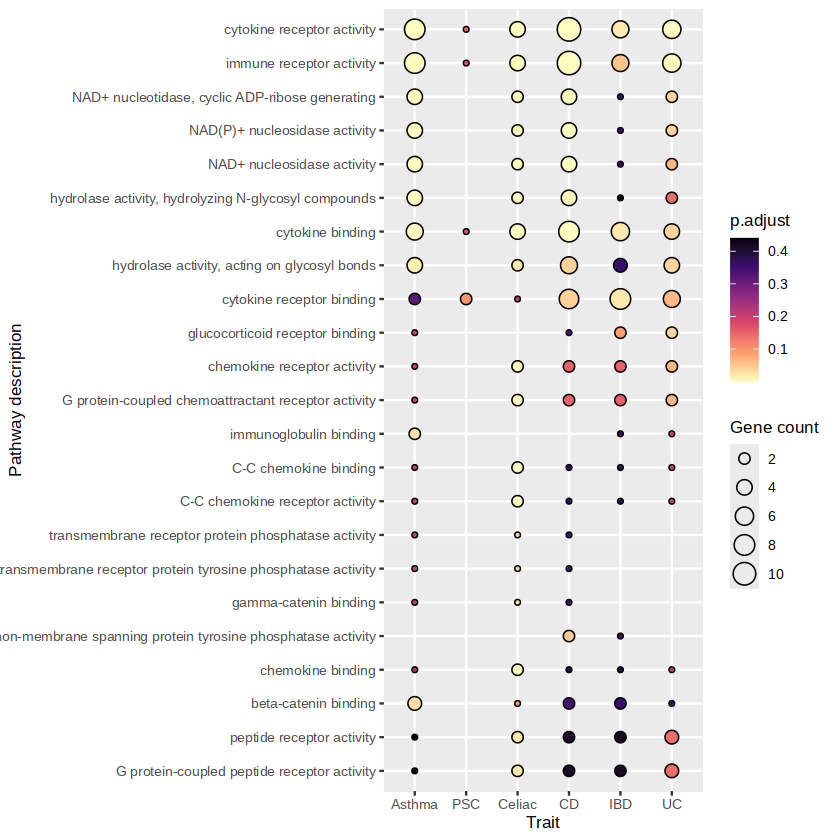

In [8]:
library(ggplot2)
library(forcats)

traitOrder <- c("Asthma", "PSC", "Celiac", "CD", "IBD", "UC")

p <- ggplot(allBound3, aes(x = fct_relevel(Trait, traitOrder), y = fct_inorder(Description), fill = p.adjust, size = `Gene count`))
q <- p + geom_point(stat = 'identity', colour="black",pch=21) + theme(text = element_text(size = 10)) + 
scale_fill_viridis_c(option = "magma", direction = -1) + scale_size_continuous(breaks = c(2,4,6,8,10)) + 
ylab("Pathway description") + xlab("Trait")
q
svg(file = "pathways_GO.svg", width = 6.3, height = 4.5)
q
dev.off()



In [29]:
### Identify COGS genes found in all traits. Make an enrichment map.

sigCogs2 <- sigCogs[IBD > 0.5 & UC > 0.5 & CD > 0.5 & Asthma > 0.5]
#sigCogs2 # only 2 genes

# how about only in IBD?
sigCogs3 <- sigCogs[IBD > 0.5 & UC > 0.5 & CD > 0.5]
#sigCogs3 # 16 genes. Run with ClusterProfiler
# for the background, would need to find genes profiled in all three traits.
ibd_genes <- cd_astao_uc_ibd_cel_psc[!is.na(IBD) & !is.na(UC) & !is.na(CD)]
ibd_genes[ensg %in% sigCogs3$ensg, cogs := 0.6]
ibd_genes[!ensg %in% sigCogs3$ensg, cogs := 0.4] # for the GO function, basically.

#ibd_genes

fwrite_headers(ibd_genes, file = "./IBD_core_COGS_genes.txt")

# get genes back
annot <- fread("../COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
annot_small <- annot[, .(ensg, gene)]
sigCogs3_annot <- annot_small[ibd_genes, on = "ensg"]

sigCogs3_annot
fwrite_headers(sigCogs3_annot, file = "./IBD_core_COGS_genes_annot.txt")




ensg,gene,PSC,Celiac,IBD,UC,CD,Asthma,cogs
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000166888,STAT6,0.0071568943,2.311371e-04,0.0081652212,0.0124449469,0.0149427650,0.9999691,0.4
ENSG00000283782,AC116366.7,0.0109738282,3.026497e-02,0.2062945805,0.4196977616,0.3130761411,0.9996127,0.4
ENSG00000115602,IL1RL1,0.0321678312,8.419213e-01,0.9334789074,0.7764839815,0.7148225147,0.9991336,0.6
ENSG00000115738,ID2,0.0365530890,2.865526e-03,0.0487426014,0.0144126935,0.0288979894,0.9981010,0.4
ENSG00000168685,IL7R,0.1506290003,2.671278e-03,0.0526933979,0.0758333330,0.0437010157,0.9975219,0.4
ENSG00000061273,HDAC7,0.1108838930,8.199771e-04,0.4058334802,0.8441972749,0.0210941898,0.9937370,0.4
ENSG00000197536,C5orf56,0.0104398196,2.596828e-02,0.1815521175,0.3636158870,0.1095855381,0.9889564,0.4
ENSG00000134882,UBAC2,0.1766206011,2.799042e-03,0.2519753480,0.1888821367,0.8029130873,0.9821209,0.4
ENSG00000177565,TBL1XR1,0.0340771837,1.158681e-03,0.0435044964,0.0455841388,0.0293773308,0.9713653,0.4


ensg,gene,PSC,Celiac,IBD,UC,CD,Asthma
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000115602,IL1RL1,0.032167831,0.8419213472,0.9334789,0.7764840,0.7148225,0.999133568
ENSG00000166949,SMAD3,0.058178565,0.0029597228,0.5348277,0.5328095,0.6836337,0.727192410
ENSG00000112486,CCR6,0.019866741,0.0023573801,0.9559132,0.8133789,0.7846537,0.187028617
ENSG00000143365,RORC,0.016922882,0.0064321465,0.9993027,1.0000000,0.8399885,0.144272971
ENSG00000182134,TDRKH,0.015651007,0.0064106483,0.9993981,0.9999089,0.8085660,0.129753542
ENSG00000143436,MRPL9,0.014305488,0.0060473862,0.9989071,0.9999031,0.8092234,0.115395167
ENSG00000143450,OAZ3,0.013800305,0.0059319400,0.9991722,0.9999033,0.8052067,0.115267741
ENSG00000107968,MAP3K8,0.018980024,0.0006823384,0.6142975,0.7220698,0.9892108,0.056082078
ENSG00000054983,GALC,0.022065694,0.0040869778,0.6951385,0.5401754,0.5380131,0.020734712


ensg,PSC,Celiac,IBD,UC,CD,Asthma
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000166888,0.0071568943,2.311371e-04,0.0081652212,0.0124449469,0.0149427650,0.9999691
ENSG00000283782,0.0109738282,3.026497e-02,0.2062945805,0.4196977616,0.3130761411,0.9996127
ENSG00000115602,0.0321678312,8.419213e-01,0.9334789074,0.7764839815,0.7148225147,0.9991336
ENSG00000115738,0.0365530890,2.865526e-03,0.0487426014,0.0144126935,0.0288979894,0.9981010
ENSG00000168685,0.1506290003,2.671278e-03,0.0526933979,0.0758333330,0.0437010157,0.9975219
ENSG00000061273,0.1108838930,8.199771e-04,0.4058334802,0.8441972749,0.0210941898,0.9937370
ENSG00000197536,0.0104398196,2.596828e-02,0.1815521175,0.3636158870,0.1095855381,0.9889564
ENSG00000134882,0.1766206011,2.799042e-03,0.2519753480,0.1888821367,0.8029130873,0.9821209
ENSG00000177565,0.0340771837,1.158681e-03,0.0435044964,0.0455841388,0.0293773308,0.9713653


### Supplementary tables:
(Prioritised genes): Gene name, Ensemble Gene ID, Max Gene Score, Trait/cell type with max Gene Score, Trait 1_ILC (+, -), trait 2ILC (+, -) trait 3_ILC (+, -), ... Trait 1_CD4 (+, -), Trait 2_CD4 (+, -)...
(All genes): Gene name, Ensemble Gene ID, Trait 1_ILC3 (score), Trait 2_ILC3 (score),... Trait 1_CD4 (score), Trait 2_CD4 (score)...


In [19]:
# using cd_astao_uc_ibd, all traits added together. Modify when adding additional traits.
options(scipen = 999)

# get genes back
annot <- fread("../COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
annot_small <- annot[, .(ensg, gene)]
all_annot <- annot_small[both, on = "ensg"]

head(all_annot)

# Make a column of max score
# The following assumes that there are two first cols (ensg and gene name)
myTraits <- names(all_annot[,3:ncol(all_annot)]) # I was trying to do this before with brackets around the numbers and it didn't work.
myTraits
all_annot[, maxScore := do.call(pmax, c(.SD, na.rm = TRUE)),by=c("ensg", "gene"), .SDcols=myTraits] # pmax is the parallel maxima.

### Get the name of the column with the max score. In case of ties, paste them.
# R sometimes rounds numbers under the hood. So, the following code handles:
# True zeros (0) vs. small numbers (6e-12) won't be confused
# Tolerates tiny floating-point noise (1.00000000001 vs. 1.0)
# Still works when max is very close to zero (switches to absolute check)

all_annot[, maxTrait := apply(.SD, 1, function(row) {
  names(row) <- myTraits
  if (all(is.na(row))) return(NA_character_)
  
  max_val <- max(row, na.rm = TRUE)
  
  # Define both relative and absolute tolerances
  rel_tol <- 1e-6
  abs_tol <- 1e-13
  
  is_not_na <- !is.na(row)
  
  # Relative comparison if max_val is large enough, otherwise use absolute
  if (abs(max_val) > abs_tol) {
    is_max <- abs(row - max_val) / abs(max_val) < rel_tol
  } else {
    is_max <- abs(row - max_val) < abs_tol
  }

  traits <- names(row)[which(is_not_na & is_max)]
  paste(traits, collapse = ";")
}), .SDcols = myTraits]

#print(head(unique(all_annot$maxTrait)))

### Order by max score.
setorder(all_annot, -maxScore)
#print(head(all_annot[]))
#print(head(all_annot[is.na(gene)]))
#print(head(all_annot[maxTrait %like% ";"]))

setnames(all_annot, c("ensg", "gene"), c("Ensembl Gene ID", "Gene Name"))

### Make the final raw scores table.

myTraits_genes <- c("Ensembl Gene ID", "Gene Name", myTraits)
raw_scores_table <- all_annot[, ..myTraits_genes]
# Will set the names manually now in Excel, because I want to make a header row of cell type.
#setnames(raw_scores_table, c("IBD", "UC", "CD", "PSC", "Celiac"), c("Inflammatory Bowel Disease", "Ulcerative Colitis", "Crohn's Disease", "Primary Sclerosing cholangitis", "Celiac Disease"))
fwrite_headers(raw_scores_table, file = "./raw_scores_multiCOGS_table.txt")
#print(head(raw_scores_table))

### Make the table of prioritised genes.

all_annot2 <- all_annot[rowSums(all_annot[, ..myTraits] > 0.5, na.rm = TRUE) >0]

all_annot2[, (myTraits) := lapply(.SD, function(x) {
  fifelse(is.na(x), NA_character_, # preserve NA, and make sure column is character type
          fifelse(x > 0.5, "+", "-")) # fifelse is a fast version of ifelse, from data.table
}), .SDcols = myTraits]


myTraits_genes_maxScore <- c("Ensembl Gene ID", "Gene Name", "maxScore", "maxTrait", myTraits)
summaryTable <- all_annot2[, ..myTraits_genes_maxScore]
#print(head(summaryTable))

summaryTable[maxTrait %like% ";"]
setnames(summaryTable, c("maxScore", "maxTrait"), c("Max Gene Score", "Trait(s) and cell type(s) with Max Gene Score"))
#setnames(summaryTable, c("IBD", "UC", "CD", "PSC", "Celiac"), c("Inflammatory Bowel Disease", "Ulcerative Colitis", "Crohn's Disease", "Primary Sclerosing cholangitis", "Celiac Disease"))

fwrite_headers(summaryTable, file = "./prioritised_genes_multiCOGS_table.txt")
print(head(summaryTable))
summaryTable[`Gene Name` == "CLN3"]

ensg,gene,PSC_ILC3,Celiac_ILC3,IBD_ILC3,UC_ILC3,CD_ILC3,Asthma_ILC3,PSC_CD4,Celiac_CD4,IBD_CD4,UC_CD4,CD_CD4,Asthma_CD4
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000166949,SMAD3,0.058178565,0.0029597228,0.534827717,0.53280955,0.68363374,0.7271924,0.081717900,0.0035685647,1.00000000,0.99986848,1.00000000,1.0000000
ENSG00000169189,NSMCE1,0.018707027,0.0008029313,0.016347843,0.01795734,0.04407426,0.8939787,0.031779055,0.0019654982,0.03719501,0.03432812,0.10873823,0.9999998
ENSG00000166888,STAT6,0.007156894,0.0002311371,0.008165221,0.01244495,0.01494276,0.9999691,0.009927248,0.0002505305,0.01247468,0.01809688,0.01901289,0.9999688
ENSG00000197536,C5orf56,0.010439820,0.0259682772,0.181552118,0.36361589,0.10958554,0.9889564,0.014129594,0.0306024333,0.56065789,0.68153319,0.33663877,0.9995591
ENSG00000283782,AC116366.7,0.010973828,0.0302649697,0.206294580,0.41969776,0.31307614,0.9996127,0.014129594,0.0306024333,0.56065789,0.68153319,0.33663877,0.9995591
ENSG00000061273,HDAC7,0.110883893,0.0008199771,0.405833480,0.84419727,0.02109419,0.9937370,0.113111460,0.0008873337,0.46745404,0.87690767,0.02479899,0.9960799


[1] "PSC_ILC3"    "Celiac_ILC3" "IBD_ILC3"    "UC_ILC3"     "CD_ILC3"    
 [6] "Asthma_ILC3" "PSC_CD4"     "Celiac_CD4"  "IBD_CD4"     "UC_CD4"     
[11] "CD_CD4"      "Asthma_CD4"

Ensembl Gene ID,Gene Name,maxScore,maxTrait,PSC_ILC3,Celiac_ILC3,IBD_ILC3,UC_ILC3,CD_ILC3,Asthma_ILC3,PSC_CD4,Celiac_CD4,IBD_CD4,UC_CD4,CD_CD4,Asthma_CD4
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ENSG00000166949,SMAD3,1.0000000,IBD_CD4;CD_CD4;Asthma_CD4,-,-,+,+,+,+,-,-,+,+,+,+
ENSG00000112294,ALDH5A1,1.0000000,PSC_ILC3;PSC_CD4,+,NA,-,-,-,-,+,NA,-,-,-,-
ENSG00000178828,RNF186,1.0000000,IBD_ILC3;UC_ILC3;IBD_CD4;UC_CD4,-,-,+,+,-,-,-,-,+,+,-,-
ENSG00000162894,FCMR,1.0000000,IBD_CD4;UC_CD4;CD_CD4,-,-,-,-,-,-,-,-,+,+,+,-
ENSG00000168453,HR,1.0000000,IBD_ILC3;IBD_CD4,-,-,+,+,-,-,-,-,+,+,-,-
ENSG00000142224,IL19,1.0000000,IBD_CD4;UC_CD4,-,-,-,-,-,-,-,-,+,+,+,-
ENSG00000143365,RORC,1.0000000,UC_ILC3;UC_CD4,-,-,+,+,+,-,-,-,+,+,+,-
ENSG00000143226,FCGR2A,1.0000000,IBD_ILC3;UC_ILC3;IBD_CD4;UC_CD4,-,-,+,+,-,+,-,-,+,+,-,+
ENSG00000136634,IL10,1.0000000,IBD_CD4;UC_CD4,-,-,+,+,+,-,-,-,+,+,+,-


   Ensembl Gene ID Gene Name Max Gene Score
1: ENSG00000166949     SMAD3              1
2: ENSG00000112294   ALDH5A1              1
3: ENSG00000178828    RNF186              1
4: ENSG00000162894      FCMR              1
5: ENSG00000168453        HR              1
6: ENSG00000142224      IL19              1
   Trait(s) and cell type(s) with Max Gene Score PSC_ILC3 Celiac_ILC3 IBD_ILC3
1:                     IBD_CD4;CD_CD4;Asthma_CD4        -           -        +
2:                              PSC_ILC3;PSC_CD4        +        <NA>        -
3:               IBD_ILC3;UC_ILC3;IBD_CD4;UC_CD4        -           -        +
4:                         IBD_CD4;UC_CD4;CD_CD4        -           -        -
5:                              IBD_ILC3;IBD_CD4        -           -        +
6:                                IBD_CD4;UC_CD4        -           -        -
   UC_ILC3 CD_ILC3 Asthma_ILC3 PSC_CD4 Celiac_CD4 IBD_CD4 UC_CD4 CD_CD4
1:       +       +           +       -          -       +      +   

Ensembl Gene ID,Gene Name,Max Gene Score,Trait(s) and cell type(s) with Max Gene Score,PSC_ILC3,Celiac_ILC3,IBD_ILC3,UC_ILC3,CD_ILC3,Asthma_ILC3,PSC_CD4,Celiac_CD4,IBD_CD4,UC_CD4,CD_CD4,Asthma_CD4
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ENSG00000188603,CLN3,0.5955591,CD_ILC3,-,-,+,-,+,-,-,-,-,-,-,-


## No. genes per cell type/trait?
## And look for ILC3-specific genes across traits
Filter based on + in ILC3 (any trait) and not + in CD4 (any trait).


In [31]:
ILC3 <- c("PSC_ILC3", "Celiac_ILC3", "IBD_ILC3", "UC_ILC3", "CD_ILC3", "Asthma_ILC3")
CD4 <- c("PSC_CD4", "Celiac_CD4", "IBD_CD4", "UC_CD4", "CD_CD4", "Asthma_CD4")

summaryTable[, ILC3 := rowSums(.SD == "+", na.rm = TRUE) > 0, .SDcols = ILC3]
summaryTable[, CD4 := rowSums(.SD == "+", na.rm = TRUE) > 0, .SDcols = CD4]
summaryTable[, ILC3_specific := get("ILC3") & !get("CD4")]
summaryTable[, CD4_specific := get("CD4") & !get("ILC3")]

table(summaryTable[, .(ILC3_specific)]) # 66 genes
table(summaryTable[, .(CD4_specific)])
table(summaryTable[, .(ILC3)])
table(summaryTable[, .(CD4)])


ILC3 <- summaryTable[ILC3_specific == TRUE]
unique(sort(ILC3$`Gene Name`))

#### See if these genes are enriched in any biological pathways?
forFUMA <- unique(ILC3[, .(`Ensembl Gene ID`)])
fwrite(forFUMA, file = "./ILC3_specific_genes_multiTrait.txt", sep = "\t", quote = F, row.names = F, col.names = F)



FALSE  TRUE 
  266    66 


FALSE  TRUE 
  251    81 


FALSE  TRUE 
   81   251 


FALSE  TRUE 
   66   266 

[1] "AHSA1"        "BCL6"         "BTN2A1"       "BTN3A1"       "BTN3A2"      
 [6] "C6orf58"      "CCR2"         "CCR6"         "CFL1"         "CLN3"        
[11] "DACT3"        "DDC"          "DGKG"         "DIEXF"        "DLD"         
[16] "EAF2"         "ERG"          "GADD45A"      "GPR22"        "HCLS1"       
[21] "HOXA11"       "ID2"          "IGFL2"        "IL12RB2"      "IL15RA"      
[26] "IL17A"        "IL17REL"      "IL18R1"       "IL1R1"        "INO80D"      
[31] "IQCB1"        "KCP"          "KIAA0408"     "KLRB1"        "KXD1"        
[36] "MCM3"         "MRPL9"        "MUS81"        "NRCAM"        "OR2A4"       
[41] "PCBP3"        "PFKM"         "PNMAL1"       "PRKD2"        "PRRG2"       
[46] "PTPRK"        "RAPGEF3"      "RIPK2"        "RNF217"       "RP11-211G3.2"
[51] "RPAP3"        "SALL4"        "SELL"         "SESN1"        "SLC1A5"      
[56] "SLC34A1"      "SLC48A1"      "SOGA3"        "SPRY4"        "TBL1XR1"     
[61] "TFF1"         "TNFSF18"      "TNFSF4"       "UBE2F"        "VIPAS39"     
[66] "VNN2"

In [49]:
raw_scores_table[`Gene Name` == "IL18R1"]

summaryTable[Asthma_ILC3 == "+" & CD_ILC3 == "+"]

Ensembl Gene ID,Gene Name,PSC_ILC3,Celiac_ILC3,IBD_ILC3,UC_ILC3,CD_ILC3,Asthma_ILC3,PSC_CD4,Celiac_CD4,IBD_CD4,UC_CD4,CD_CD4,Asthma_CD4
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000115604,IL18R1,0.01855212,0.7948101,0.3436917,0.2170626,0.5762807,0.6485096,0.0138194,0.06935144,0.1332108,0.1116701,0.4764169,0.1852237


Ensembl Gene ID,Gene Name,Max Gene Score,Trait(s) and cell type(s) with Max Gene Score,PSC_ILC3,Celiac_ILC3,IBD_ILC3,UC_ILC3,CD_ILC3,Asthma_ILC3,PSC_CD4,Celiac_CD4,IBD_CD4,UC_CD4,CD_CD4,Asthma_CD4,ILC3,CD4,ILC3_specific,CD4_specific
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
ENSG00000166949,SMAD3,1.0000000,IBD_CD4;CD_CD4;Asthma_CD4,-,-,+,+,+,+,-,-,+,+,+,+,TRUE,TRUE,FALSE,FALSE
ENSG00000115602,IL1RL1,0.9991336,Asthma_ILC3,-,+,+,+,+,+,-,-,-,-,+,+,TRUE,TRUE,FALSE,FALSE
ENSG00000134882,UBAC2,0.9821209,Asthma_ILC3,-,-,-,-,+,+,-,-,+,-,+,+,TRUE,TRUE,FALSE,FALSE
ENSG00000172673,THEMIS,0.8969473,Asthma_CD4,-,+,-,-,+,+,-,+,-,-,+,+,TRUE,TRUE,FALSE,FALSE
ENSG00000169508,GPR183,0.8910482,Asthma_ILC3,-,-,-,-,+,+,-,-,-,-,+,+,TRUE,TRUE,FALSE,FALSE
ENSG00000134460,IL2RA,0.8793540,PSC_ILC3,+,-,-,-,+,+,-,-,+,-,+,+,TRUE,TRUE,FALSE,FALSE
ENSG00000115607,IL18RAP,0.8380066,IBD_CD4,-,-,-,+,+,+,-,-,+,+,+,+,TRUE,TRUE,FALSE,FALSE
ENSG00000115604,IL18R1,0.7948101,Celiac_ILC3,-,+,-,-,+,+,-,-,-,-,-,-,TRUE,FALSE,TRUE,FALSE
ENSG00000152894,PTPRK,0.7797516,Asthma_ILC3,-,+,-,-,+,+,-,-,-,-,-,-,TRUE,FALSE,TRUE,FALSE


In [8]:
load("~/HRJ_monocytes/hILCs/COGS_results/COGS_out/Version3_revision2/CD_noimpute_check_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Rsession_preCOGS.RData")
setwd("/rds/general/project/lms-spivakov-analysis/live/HRJ_monocytes/hILCs/COGS_results")
cd <- fread("./COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/COGS_scores_data.table.txt")
astao <- fread("./COGS_out/ASTAO_Ferreira_30929738/ASTAO_Ferreira_30929738_ILC3_SuSIE/COGS_scores_data.table.txt")
uc <- fread("./COGS_out/UC_DeLange_28067908//UC_DeLange_28067908_ILC3_SuSIE/COGS_scores_data.table.txt")
ibd <- fread("./COGS_out/IBD_DeLange_28067908/IBD_DeLange_28067908_ILC3_SuSIE/COGS_scores_data.table.txt")
cel <- fread("./COGS_out/CEL_Dubois_20190752/CEL_Dubois_20190752_ILC3_SuSIE/COGS_scores_data.table.txt")
psc <- fread("./COGS_out/PSC_Ji_27992413/PSC_Ji_27992413_ILC3_SuSIE/COGS_scores_data.table.txt")

[1] 18459

[1] 18538

In [4]:
str(csnps)
  

Classes ‘data.table’ and 'data.frame':	73866 obs. of  3 variables:
 $ chr : num  1 1 1 1 1 1 1 1 1 1 ...
 $ pos : int  930248 957189 963086 978953 979472 979560 980234 999842 1014228 1041249 ...
 $ ensg: chr  "ENSG00000187634" "ENSG00000188976" "ENSG00000187961" "ENSG00000187642" ...
 - attr(*, ".internal.selfref")=<externalptr> 


In [8]:
library(data.table)
library(dplyr)
my_gwas[, chr := as.character(chr)]
csnps[, chr := as.character(chr)]
digest[, chr := as.character(chr)]
overall.scores <- compute_cogs(my_gwas,csnps,digest,feature.sets)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Extracting coding SNPs

Mapping SNPs to restriction fragments

Gathering fragments of interest

feature.names argument missing - will compute the score using baitID_5kb,oeID_5kb,N_fres,N_5kb,N_abc,chicago_score_fres,chicago_score_5kb,ABC.Score,VProm,coding_snp

Adding coding SNPs

Computing COGS scores

Will compute the scores using baitID_5kb,oeID_5kb,N_fres,N_5kb,N_abc,chicago_score_fres,chicago_score_5kb,ABC.Score,VProm,coding_snp



In [10]:
overall.scores
TSS <- fread("/rds/general/project/lms-spivakov-analysis/live/HRJ_monocytes/external_data/ensembl/for_rCOGS_testing/ANNOTATIONS_EnsemblHavanaMerge_plusHavana_V88hg38_V107hg19.txt")
message("Annotating the COGS results using TSS from /rds/general/project/lms-spivakov-analysis/live/HRJ_monocytes/external_data/ensembl/for_rCOGS_testing/ANNOTATIONS_EnsemblHavanaMerge_plusHavana_V88hg38_V107hg19.txt")

###
annot.scores <- TSS[overall.scores, on = "ensg"]



ensg,cogs
<chr>,<dbl>
ENSG00000142609,1.610851e-03
ENSG00000187730,1.593634e-03
ENSG00000067606,4.632808e-02
ENSG00000116151,9.393921e-03
ENSG00000157916,3.630873e-02
ENSG00000162585,4.151960e-03
ENSG00000157933,6.450199e-03
ENSG00000160075,2.506487e-02
ENSG00000008130,1.073353e-03


Annotating the COGS results using TSS from /rds/general/project/lms-spivakov-analysis/live/HRJ_monocytes/external_data/ensembl/for_rCOGS_testing/ANNOTATIONS_EnsemblHavanaMerge_plusHavana_V88hg38_V107hg19.txt



In [14]:
setorder(annot.scores, -cogs)
annot.scores[gene == "CLN3"]

ensg,chr37,chr38,gene,biotype,minTss37,maxTss37,minTss38,maxTss38,cogs
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>
ENSG00000188603,16,16,CLN3,protein_coding,28493698,28506896,28484014,28495575,0.6209149


In [15]:
# run the comparison script.
library(data.table)
library(dplyr)
library(ggplot2)
library(ggrepel)

mydir <- "/rds/general/project/lms-spivakov-analysis/live/HRJ_monocytes/hILCs/COGS_results/"
#mydir <- "~/Documents/analysis/hILCs/"
results <- paste0(mydir, "COGS_out")
outdir = paste0(mydir, "comparisons")
#dir.create(outdir)
list.files(results)

### Compare CD4 with ILC? this is sort of already done
### Compare allergic disease Javierre with Allergic disease ILC, just to see how best to represent.

##### To run with pre-annotated results
make_comparison_plot_annotated <- function(res1, name1, res2, name2, outdir, outname, imageType) {
  results1 <- fread(paste(results, res1, sep = "/"))
  results2 <- fread(paste(results, res2, sep = "/"))
  results1[, chr37 := as.character(chr37)]
  results2[, chr37 := as.character(chr37)]
  results1[, chr38 := as.character(chr38)]
  results2[, chr38 := as.character(chr38)]
  
  setkey(results1, ensg, chr37, chr38, gene, minTss37, maxTss37, minTss38, maxTss38)
  
  both <- merge.data.table(results1, results2, on = c("ensg", "chr37", "chr38", "gene", "minTss37", "maxTss37", "minTss38", "maxTss38"), all = TRUE)
  
  both[cogs.x >= 0.5 & cogs.y < 0.5, ':=' (label = gene, 
                                         group = name1)]
  both[cogs.x < 0.5 & cogs.y >= 0.5, ':=' (label = gene, 
                                         group = name2)]
  both[cogs.x >= 0.5 & cogs.y >= 0.5, ':=' (label = gene, 
                                          group = "Standard and MultiCOGS")]

  # Fix NAs 
  both[cogs.x >= 0.5 & is.na(cogs.y), ':=' (group = name1,
                                           label = gene, 
                                           cogs.y = 0)]
  
  both[is.na(cogs.x) & cogs.y >= 0.5, ':=' (group = name2, 
                                            label = gene, 
                                            cogs.x = 0)]

  
  cogs1 <- paste0("cogs_", name1)
  cogs2 <- paste0("cogs_", name2)
  
  setnames(both, "cogs.x", cogs1)
  setnames(both, "cogs.y", cogs2)
  
  # Make a scatter plot.
  if(imageType == "pdf") {
    pdf(file = paste0(outdir, outname, ".pdf"), width = 9, height = 9)
    p <- ggplot(both, aes(x = get(cogs1), y = get(cogs2), label = label, colour = group))
    
    print(p + geom_point() +
            geom_text_repel(aes(label = label),
                            #box.padding   = 0.2, 
                            #point.padding = 0.2,
                            segment.color = 'grey50',
                            size = 4, 
                            max.overlaps = 50) + 
            theme(text = element_text(size = 20), panel.background = element_rect(fill = "white", colour = "grey50"), 
                  legend.position = "bottom") +
            xlab(name1) +
            ylab(name2)) 
    dev.off()
    } else { 
      if(imageType == "jpeg") {
        jpeg(file = paste0(outdir, outname, ".jpg"))
        p <- ggplot(both, aes(x = get(cogs1), y = get(cogs2), label = label, colour = group))
        print(p + geom_point() +
                geom_text_repel(aes(label = label),
                                #box.padding   = 0.2, 
                                #point.padding = 0.2,
                                segment.color = 'grey50',
                                size = 3, 
                                max.overlaps = 50) + 
                xlab(name1) +
                ylab(name2) +
                theme_classic())
        dev.off() 
        } else { if(imageType == "png") {
          png(file = paste0(outdir, outname, ".png"))
          p <- ggplot(both, aes(x = get(cogs1), y = get(cogs2), label = label, colour = group))
          print(p + geom_point() +
                  geom_text_repel(aes(label = label),
                                  #box.padding   = 0.2, 
                                  #point.padding = 0.2,
                                  segment.color = 'grey50',
                                  size = 3, 
                                  max.overlaps = 50) + 
                  xlab(name1) +
                  ylab(name2) +
                  theme_classic())
          dev.off() 
        } else { print("Please specify pdf, jpeg or png")
        }
        }
    }
  return(both)
}
#####

[1] "Archive"                                                     
 [2] "ASTAO_Ferreira_30929738"                                     
 [3] "ASTE_Ferreira_29083406"                                      
 [4] "IBD_DeLange_28067908"                                        
 [5] "multiCOGS_ILC3_traits"                                       
 [6] "natGen_submission1_ILCs"                                     
 [7] "revision_CD_deLange_ILCs_hg38_SuSIE_combinedInteractions_ALL"
 [8] "UC_DeLange_28067908"                                         
 [9] "Version2_revision1"                                          
[10] "Version3_revision2"

In [18]:
ILC3_impute <- make_comparison_plot_annotated(res1 = "Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt", 
                                                   name1 = "ILC3_multiCOGS_score_CD", 
                                                   res2 = "Version3_revision2/CD_noimpute_check_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt", 
                                                   name2 = "ILC3_no_impute_in_nonsig_blocks", 
                                                   outdir = paste0(mydir, "comparisons/"), 
                                                   outname = "check_noImpute_in_nonSig_blocks_ILC3_CD)multiCOGS", 
                                                   imageType = "pdf")

Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18350 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


In [17]:
sig <- annot.scores[cogs > 0.5]
nrow(sig) # 108

[1] 108

In [15]:
### Check celiac. How many blocks with imputation?
CEL <- fread("~/HRJ_monocytes/external_data/gwas/SuSIE/CEL_Dubois_20190752_1-hg38.csv")
#CEL[!is.na(pip_set_1)]
range(CEL$pip_set_1, na.rm = T)

CEL[single.pp > 0.1]

CEL_gwas <- fread("")

[1] 0.0000000000000000000002363956 0.9657955394429600382011358306

snp,block,beta,varbeta,r2pred,pip,pip_set_1,single.pp
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9:97977842,chr9_block45,-0.13559065,0.0009797700,NA,NA,NA,0.1155453
9:89706374,chr9_block42,0.14928170,0.0009974644,NA,NA,NA,0.4424346
9:5490522,chr9_block5,0.13278111,0.0008631534,NA,NA,NA,0.2388927
9:273160,chr9_block0,-0.14410034,0.0010659002,NA,NA,NA,0.1659146
8:95966520,chr8_block63,-0.17614070,0.0014849547,NA,NA,NA,0.2478422
8:95893417,chr8_block63,-0.19116051,0.0018290880,NA,NA,NA,0.1628132
8:66276046,chr8_block47,-0.16005139,0.0012308844,NA,NA,NA,0.2990912
8:128252343,chr8_block80,-0.13719524,0.0009455992,NA,NA,NA,0.1865300
8:102102345,chr8_block65,-0.12375081,0.0007171911,NA,NA,NA,0.2919632


In [9]:
?range

range {base},R Documentation
...,any numeric or character objects.
na.rm,"logical, indicating if NA's should be omitted."
finite,"logical, indicating if all non-finite elements should be omitted."
